# Clasificación y Optimización de Hiperparámetros (Core)

## Description

Objetivo: Implementar un pipeline completo de machine learning para un problema de clasificación utilizando técnicas de preprocesamiento, modelado, y optimización de hiperparámetros. Enfocar especialmente en la limpieza de datos y la optimización utilizando GridSearchCV y RandomizedSearchCV.



Dataset: Medical Cost Personal Dataset


Descripción del Dataset: El dataset de costos médicos personales contiene información sobre varios factores que afectan los costos de seguros médicos, como la edad, el sexo, el índice de masa corporal, y el hábito de fumar. Este dataset es ideal para practicar técnicas de preprocesamiento y optimización de modelos debido a la presencia de datos sucios y variables tanto categóricas como numéricas.





## Instrucciones


1. Carga y Exploración Inicial de Datos:
* Cargar el dataset desde Kaggle.
* Realizar una exploración inicial para entender la estructura del dataset y las características disponibles.
* Identificar y documentar los valores faltantes y outliers en el dataset.

2. Preprocesamiento de Datos:
* Imputar valores faltantes utilizando técnicas adecuadas (media, mediana, moda, imputación avanzada).
* Codificar variables categóricas utilizando One-Hot Encoding.
* Escalar características numéricas utilizando StandardScaler.

3. Implementación de Modelos de Clasificación:
* Entrenar y evaluar al menos tres modelos de clasificación diferentes: Regresión Logística, K-Nearest Neighbors (KNN), y Árbol de Decisión.
* Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.

4. Optimización de Hiperparámetros:
* Implementar GridSearchCV para optimizar los hiperparámetros de los modelos seleccionados.
* Implementar RandomizedSearchCV como método alternativo de optimización.
* Comparar los resultados de GridSearchCV y RandomizedSearchCV para los modelos optimizados.

5. Evaluación de Modelos:
* Evaluar los modelos optimizados utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
* Generar y analizar la matriz de confusión para los modelos optimizados.
* Crear y visualizar la curva ROC para evaluar la capacidad del modelo para distinguir entre clases.

6. Documentación y Entrega:
* Documentar todos los pasos del proceso en un notebook de Jupyter, incluyendo explicaciones detalladas y justificaciones para cada decisión tomada.
* Subir el notebook y los resultados a un repositorio de GitHub.
* Crear un tag de liberación (v1.0.0) para esta versión del proyecto en GitHub.


## Entregables

- Notebook de Jupyter con todo el análisis y resultados.
- Documentación completa del proceso de preprocesamiento, modelado y optimización.
- Visualizaciones y análisis de las métricas de rendimiento.
- Repositorio de GitHub con el notebook y los resultados, incluyendo un tag de liberación.

# Desarrollo

## 1.- Carga y Exploración Inicial de Datos:
* Cargar el dataset desde Kaggle.
* Realizar una exploración inicial para entender la estructura del dataset y las características disponibles.
* Identificar y documentar los valores faltantes y outliers en el dataset.

In [158]:
# Importar librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso,LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [159]:
# Importar Pandas
import pandas as pd

# Importar desde Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [160]:
# Carga el archivo insurance.csv en un DataFrame de Pandas.
df = pd.read_csv(f"{path}/insurance.csv")

In [161]:
# Mostrar las primeras 10 filas del DataFrame
print("Muestra de 10 registros:")
df.sample(10)

Muestra de 10 registros:


,age,sex,bmi,children,smoker,region,charges
1150,18,female,30.305,0,no,northeast,2203.73595
554,25,female,41.325,0,no,northeast,17878.90068
579,25,female,23.465,0,no,northeast,3206.49135
1276,22,female,30.400,0,no,northeast,2741.94800
539,53,male,31.350,0,no,southeast,27346.04207
984,20,male,30.115,5,no,northeast,4915.05985
336,60,male,25.740,0,no,southeast,12142.57860
558,35,female,34.105,3,yes,northwest,39983.42595
54,40,female,28.690,3,no,northwest,8059.67910
798,58,female,33.100,0,no,southwest,11848.14100


In [162]:
# Obtener información sobre el DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


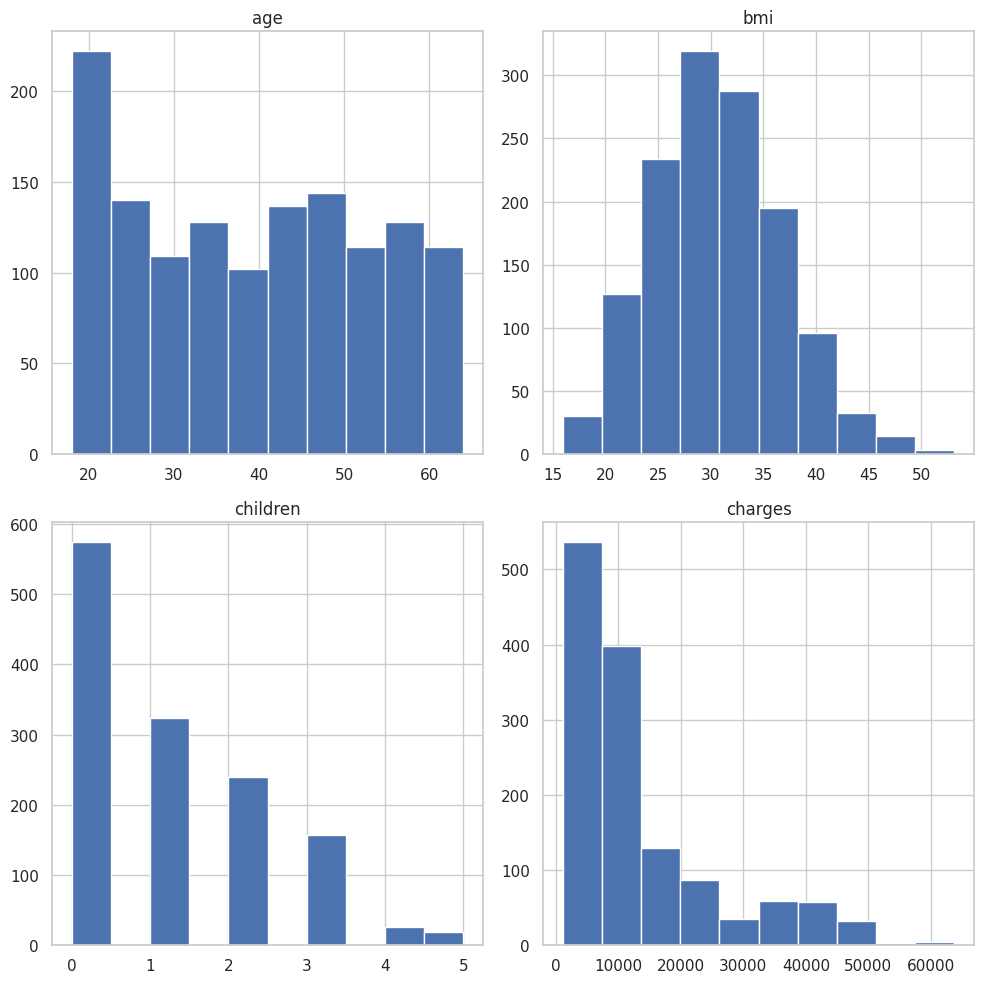

In [163]:
# resumo en un solo coando las distribuciones de todas las variables
import matplotlib.pyplot as plt
df.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()

La variable *"bmi"* tiene una distribución normal, el resto no

In [164]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [165]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


### Identificar valores faltantes, duplicados y outliers.

In [166]:
# reviso los nulos por columna
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [167]:
for c in df.columns:
    print()
    print(f'{c}: {df[c].duplicated().sum()}')


age: 1291

sex: 1336

bmi: 790

children: 1332

smoker: 1336

region: 1334

charges: 1


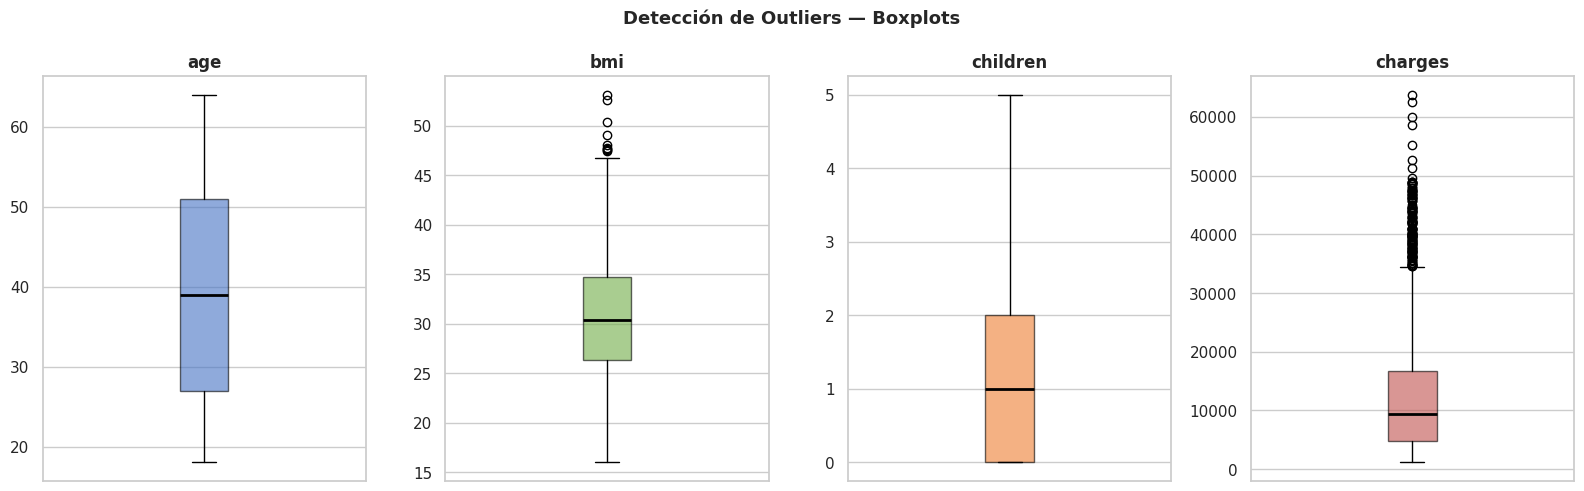

In [168]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Detección de Outliers — Boxplots', fontsize=13, fontweight='bold')
num_cols = df.select_dtypes(include='number').columns
colores = ['#4472C4','#70AD47','#ED7D31','#C0504D']
for ax, col, color in zip(axes, num_cols, colores):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', lw=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xticks([])
plt.tight_layout()
plt.show()

Existen valores atipicos, principalmente en *"charges"* tiene outliers significativos hacia valores altos.

### Eliminar duplicados.

In [169]:
print(f"Filas duplicadas: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape tras eliminar duplicados: {df.shape}")

Filas duplicadas: 1
Shape tras eliminar duplicados: (1337, 7)


In [170]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


In [171]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [172]:
# Revisa los valores unicos por columna, me permite reconocer que datos contiene cada columna
for c in df.columns:
    print()
    print(f'{c}: {df[c].nunique()}')
    print(f'{c}: {df[c].unique()}')



age: 47
age: [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]

sex: 2
sex: ['female' 'male']

bmi: 548
bmi: [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 

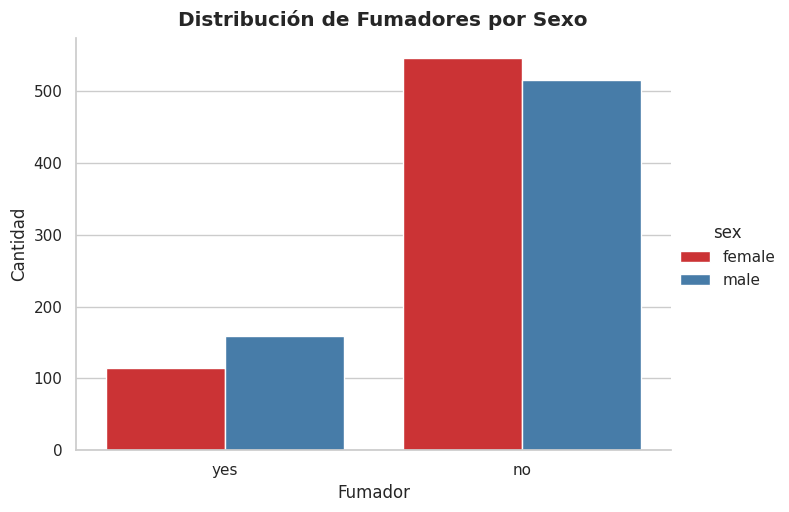

In [173]:
g = sns.catplot(x='smoker', kind='count', hue='sex',
                palette='Set1', data=df, height=5, aspect=1.4)
g.set_axis_labels('Fumador', 'Cantidad')
g.fig.suptitle('Distribución de Fumadores por Sexo', fontweight='bold', y=1.02)
plt.show()


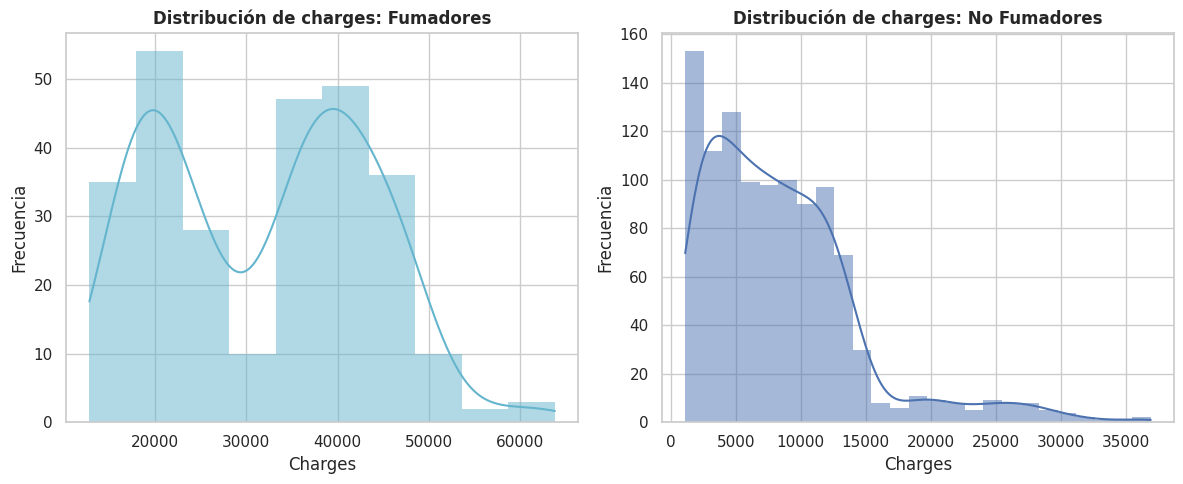

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribución para fumadores
sns.histplot(df[df['smoker'] == 'yes']['charges'], color='c', ax=axes[0], kde=True, linewidth=0)
axes[0].set_title('Distribución de charges: Fumadores', fontweight='bold')
axes[0].set_xlabel('Charges')
axes[0].set_ylabel('Frecuencia')

# Distribución para no fumadores
sns.histplot(df[df['smoker'] == 'no']['charges'], color='b', ax=axes[1], kde=True, linewidth=0)
axes[1].set_title('Distribución de charges: No Fumadores', fontweight='bold')
axes[1].set_xlabel('Charges')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

los fumadores presentan costos médicos mucho más altos y con una distribución bimodal — indicativo de dos subgrupos de riesgo.

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


### Matriz de Correlación

In [176]:
# Correlación usando solo las variables numericas
correlacion = df.select_dtypes(include=['number']).corr()
correlacion

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


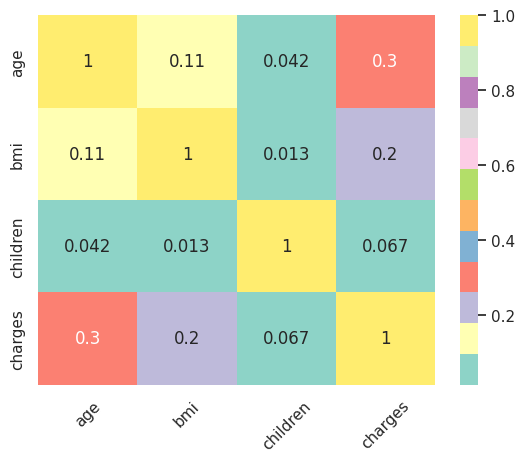

In [177]:
import seaborn as sns
sns.heatmap(correlacion, annot=True, cmap='Set3')
plt.xticks(rotation=45)
plt.show()

'charges' tiene la mayor correlación con 'age' (0.30) y con 'bmi' (0.20). Ninguna correlación es muy alta. No hay multicolinealidad grave.

## 2.- Preprocesamiento de Datos:
* Imputar valores faltantes utilizando técnicas adecuadas (media, mediana, moda, imputación avanzada).
* Codificar variables categóricas utilizando One-Hot Encoding.
* Escalar características numéricas utilizando StandardScaler.

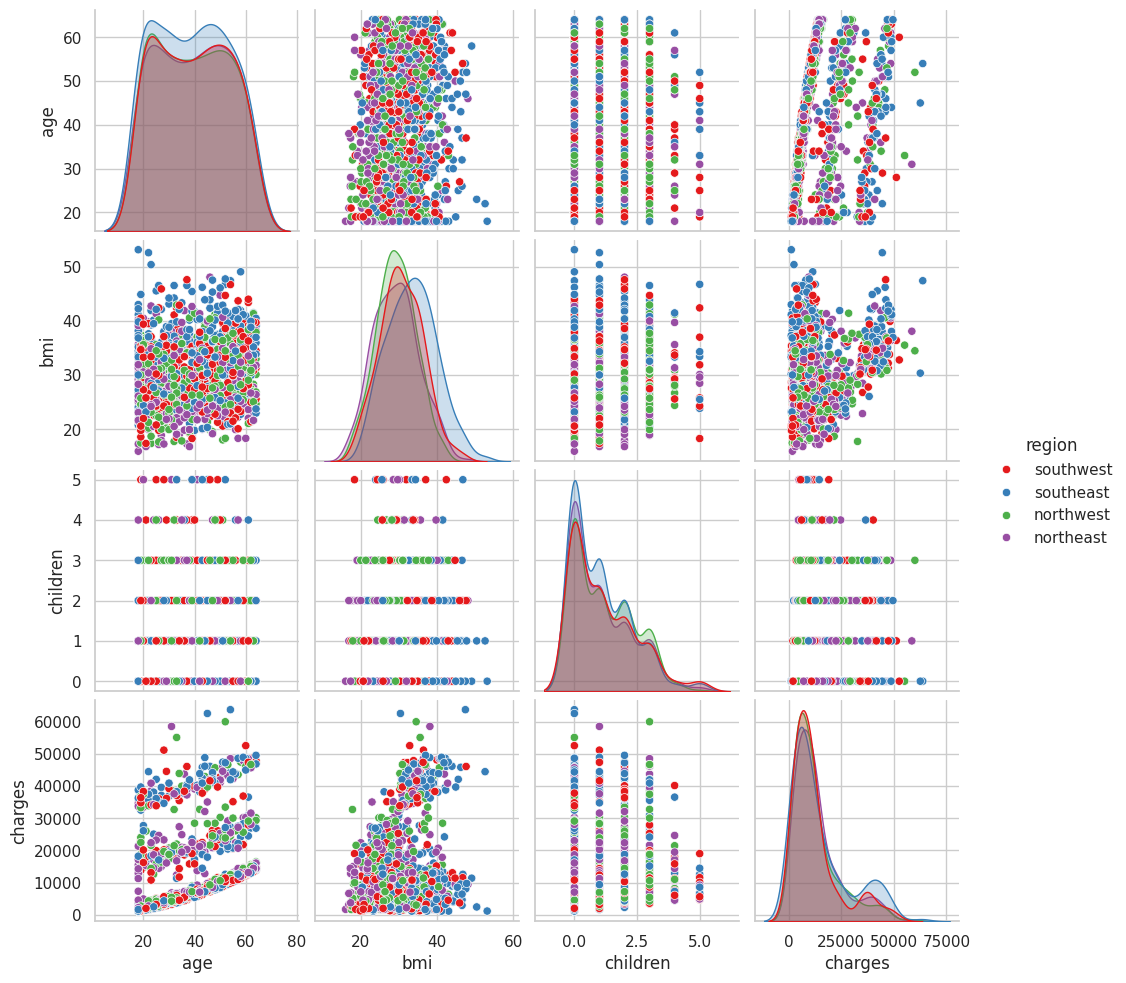

In [178]:
sns.pairplot(df, hue="region", palette="Set1")
plt.show()

Elegí la variable objetivo ‘region’
Los grupos de región se superponen bastante.
No hay separación lineal clara entre regiones.

In [179]:
df1 = df.copy()

In [180]:
# Elimino las columnas ID porque no me interesan
#df1=df1.drop(columns=['Customer ID', 'Transaction ID', 'Date'])

In [181]:
X = df1.drop(columns=['region']) # El resto Exepto variable objetivo

In [182]:
y = df1['region'] # Variable objetivo

In [183]:
from sklearn.model_selection import train_test_split

#  Dividir en train/test correctamente
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% para test, 80% para train
    random_state=42,         # ← MUY IMPORTANTE: fija la aleatoriedad para que el resultado sea reproducibleç
    stratify=y               # ← IMPORTANTE: estratificar por la variable objetivo
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')
print(f'Suma OK: {len(X_train) + len(X_test) == len(X)}')



print('\nProporciones de clases en y_train:')
print(y_train.value_counts(normalize=True) * 100)
print('\nProporciones de clases en y_test:')
print(y_test.value_counts(normalize=True) * 100)
print('\n👉 Las proporciones se mantienen — el stratify funcionó.')

X_train: (1069, 6), X_test: (268, 6)
y_train: (1069,), y_test: (268,)
Suma OK: True

Proporciones de clases en y_train:
region
southeast    27.221703
southwest    24.321796
northwest    24.228251
northeast    24.228251
Name: proportion, dtype: float64

Proporciones de clases en y_test:
region
southeast    27.238806
northwest    24.253731
northeast    24.253731
southwest    24.253731
Name: proportion, dtype: float64

👉 Las proporciones se mantienen — el stratify funcionó.


In [184]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [185]:
# Indico columnas a mano
cols_nom = ['sex', 'smoker']
cols_ord = []
cols_nonorm =['age','children', 'charges'] #
cols_norm = ['bmi']

preprocesador = make_column_transformer(
    (OneHotEncoder(),   cols_nom),
    (OrdinalEncoder(), cols_ord),
    (MinMaxScaler(),   cols_nonorm),
    (StandardScaler(),  cols_norm),
    remainder='drop'   # qué hacer con columnas no listadas
)
preprocesador

ColumnTransformer(transformers=[('onehotencoder', OneHotEncoder(),
                                 ['sex', 'smoker']),
                                ('ordinalencoder', OrdinalEncoder(), []),
                                ('minmaxscaler', MinMaxScaler(),
                                 ['age', 'children', 'charges']),
                                ('standardscaler', StandardScaler(), ['bmi'])])

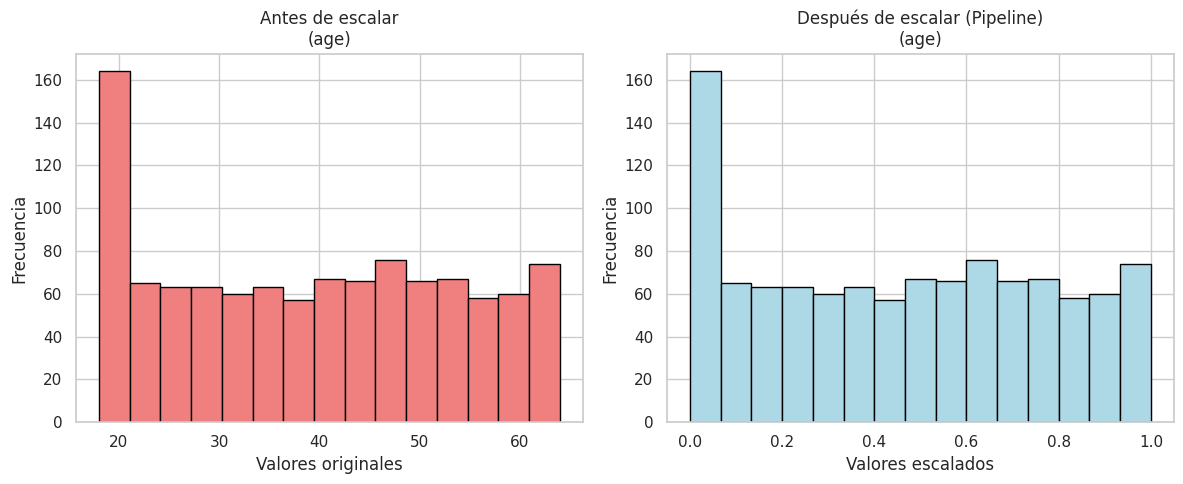

In [186]:
# Visualización de los datos antes y despues de escalar
import matplotlib.pyplot as plt

col_name = X_train.columns[0]
X_train_esc = preprocesador.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
axes[0].hist(X_train.iloc[:, 0], bins=15, color="lightcoral", edgecolor='black')
axes[0].set_title(f'Antes de escalar\n({col_name})')
axes[0].set_xlabel('Valores originales')
axes[0].set_ylabel('Frecuencia')

# Después
axes[1].hist(X_train_esc[:, 4], bins=15, color="lightblue", edgecolor='black') #
axes[1].set_title(f'Después de escalar (Pipeline)\n({col_name})')
axes[1].set_xlabel('Valores escalados')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Grafica que nos muestra la distribución con los valores originales y despues con los valores escalados

## 3.- Implementación de Modelos de Clasificación:
* Entrenar y evaluar al menos tres modelos de clasificación diferentes: Regresión Logística, K-Nearest Neighbors (KNN), y Árbol de Decisión.
* Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.


In [187]:
# 4 modelos con StandardScaler
modelos = {
    'LogReg':    make_pipeline(preprocesador, LogisticRegression(max_iter=1000, random_state=42)),
    'KNN(k=11)': make_pipeline(preprocesador, KNeighborsClassifier(n_neighbors=11)),
    'DT(d=5)':   make_pipeline(preprocesador, DecisionTreeClassifier(max_depth=5, random_state=42)),
    'RF(200)':   make_pipeline(preprocesador, RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
}

In [188]:
filas = []
for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    pred  = m.predict(X_test)

    # Calculo las probabilidades para todas las clases
    proba = m.predict_proba(X_test)

    filas.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted'),
        'Recall':    recall_score(y_test, pred, average='weighted'),
        'F1':        f1_score(y_test, pred, average='weighted'),
        'AUC':       roc_auc_score(y_test, proba, multi_class='ovr', average='weighted')
    })
tabla = pd.DataFrame(filas).set_index('Modelo').round(4)
print(tabla)

           Accuracy  Precision  Recall      F1     AUC
Modelo                                                
LogReg       0.3545     0.3489  0.3545  0.3177  0.6346
KNN(k=11)    0.3470     0.3427  0.3470  0.3406  0.5851
DT(d=5)      0.3881     0.4517  0.3881  0.3627  0.6396
RF(200)      0.3545     0.3483  0.3545  0.3500  0.6106


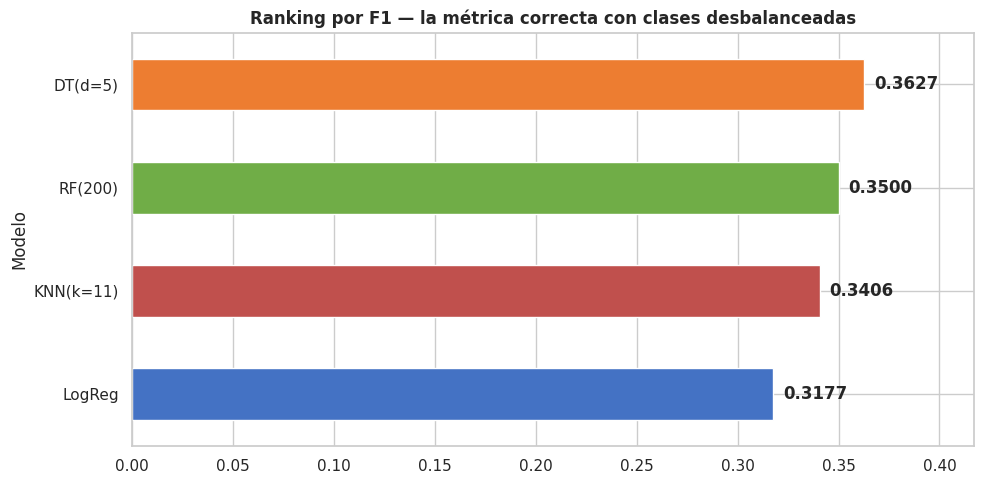


🏆 GANADOR según F1: DT(d=5) con F1 = 0.3627


In [189]:
# Barplot del F1 (la métrica clave)
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#4472C4', '#C0504D', '#70AD47', '#ED7D31']
tabla['F1'].sort_values().plot(kind='barh', color=colores, edgecolor='white', ax=ax)
for i, v in enumerate(tabla['F1'].sort_values()):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_title('Ranking por F1 — la métrica correcta con clases desbalanceadas', fontweight='bold')
ax.set_xlim(0, max(tabla['F1']) * 1.15)
plt.tight_layout(); plt.show()

ganador = tabla['F1'].idxmax()
print(f'\n🏆 GANADOR según F1: {ganador} con F1 = {tabla.loc[ganador, "F1"]:.4f}')

En este caso el ganador es DecisionTreeClassifier aunque con un F1 de 0.3627

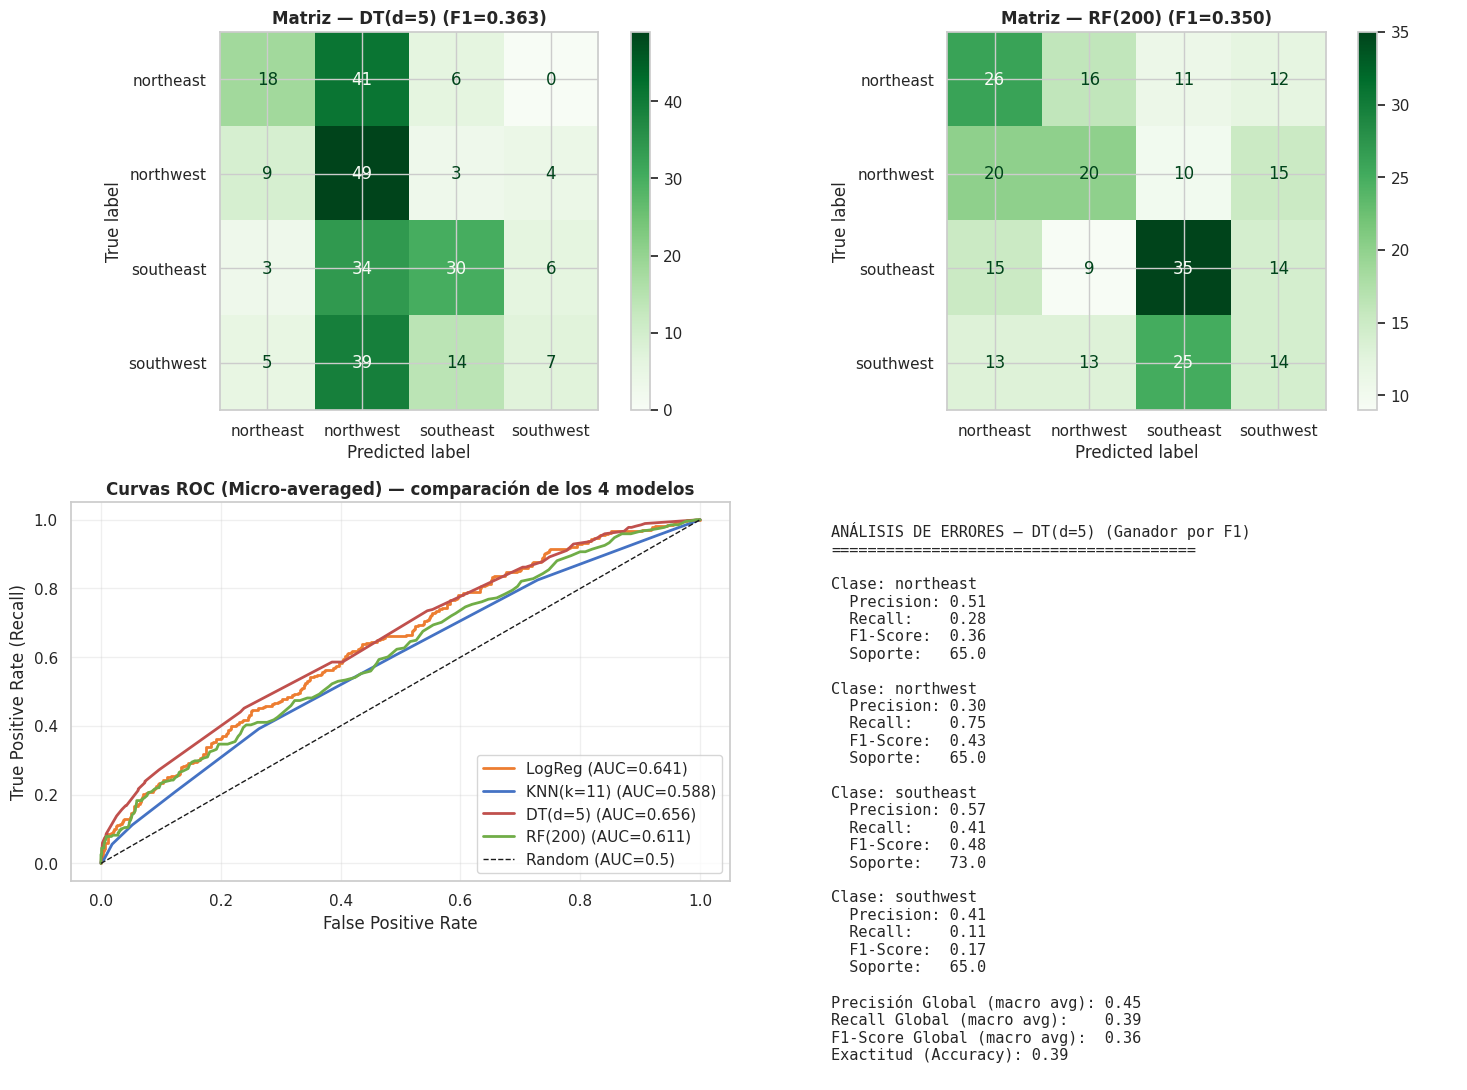

In [190]:
# Matrices de los 2 mejores + curvas ROC de los 4
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

class_labels = sorted(y_test.unique())

# Matrices de los 2 mejores por F1
ranking_f1 = tabla['F1'].sort_values(ascending=False).head(2).index.tolist()
for i, nombre in enumerate(ranking_f1):
    pred = modelos[nombre].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, ax=axes[0, i], cmap='Greens',
        display_labels=class_labels
    )
    axes[0, i].set_title(f'Matriz — {nombre} (F1={tabla.loc[nombre, "F1"]:.3f})',
                          fontweight='bold')

# Curvas ROC de los 4 modelos en el mismo gráfico
ax_roc = axes[1, 0]
colores_roc = {'KNN(k=11)':'#4472C4', 'DT(d=5)':'#C0504D', 'RF(200)':'#70AD47', 'LogReg':'#ED7D31'}
for nombre, m in modelos.items():
    from sklearn.preprocessing import label_binarize
    y_test_bin = label_binarize(y_test, classes=class_labels)
    n_classes = y_test_bin.shape[1]

    y_score = m.predict_proba(X_test)

    # Compute micro-average ROC curve and ROC area
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    auc_micro = roc_auc_score(y_test, y_score, multi_class='ovr', average='micro')

    ax_roc.plot(fpr_micro, tpr_micro, color=colores_roc[nombre], linewidth=2,
                 label=f'{nombre} (AUC={auc_micro:.3f})')

ax_roc.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate (Recall)')
ax_roc.set_title('Curvas ROC (Micro-averaged) — comparación de los 4 modelos', fontweight='bold')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

# Texto con análisis de FN para el ganador
ax_texto = axes[1, 1]
ax_texto.axis('off')

winner_model_name = tabla['F1'].idxmax()
winner_model = modelos[winner_model_name]

winner_pred = winner_model.predict(X_test)

report = classification_report(y_test, winner_pred, target_names=class_labels, output_dict=True)

text_analysis = f"""ANÁLISIS DE ERRORES — {winner_model_name} (Ganador por F1)
{'='*40}

"""
for cls_label in class_labels:
    text_analysis += f"""Clase: {cls_label}
  Precision: {report[cls_label]['precision']:.2f}
  Recall:    {report[cls_label]['recall']:.2f}
  F1-Score:  {report[cls_label]['f1-score']:.2f}
  Soporte:   {report[cls_label]['support']}

"""

text_analysis += f"""Precisión Global (macro avg): {report['macro avg']['precision']:.2f}
Recall Global (macro avg):    {report['macro avg']['recall']:.2f}
F1-Score Global (macro avg):  {report['macro avg']['f1-score']:.2f}
Exactitud (Accuracy): {report['accuracy']:.2f}
"""

ax_texto.text(0.05, 0.95, text_analysis, fontsize=11, family='monospace',
                transform=ax_texto.transAxes, va='top')

plt.tight_layout(); plt.show()

En la matriz de confusión de **DecisionTreeClassifier** podemos ver que casi todos los predijo como "northwest" mientras que el **RandomForestClassifier** tiene la linea diagonal ligeramente marcada aunque tiene una pequeña tendencia a predecir más "southeast"
Cabe destacar que en la division train/test se usó el stratify



#### Análisis de las Curvas ROC (Micro-averaged)

*   **Comparación de AUC:** El modelo optimizado por **RandomizedSearchCV (AUC = 0.666)** supera al de **GridSearchCV (AUC = 0.614)**. Un AUC de 0.666 indica que el modelo tiene una capacidad moderada para distinguir entre las 4 regiones, situándose significativamente por encima de una clasificación puramente aleatoria (AUC = 0.50).

*   **Forma de la Curva:** La curva naranja (Random Search) se mantiene consistentemente por encima de la azul (Grid Search). Esto significa que, para cualquier nivel de Tasa de Falsos Positivos (FPR), el método aleatorio ofrece una mejor Tasa de Verdaderos Positivos (Recall).

*   **Conclusión de Desempeño:** A pesar de la optimización, el valor de AUC cercano a 0.67 sugiere que el dataset no contiene variables con una correlación extremadamente fuerte hacia la ubicación geográfica, lo que impone un "techo" natural al rendimiento de cualquier clasificador en esta tarea específica.

## 4.- Optimización de Hiperparámetros:
* Implementar GridSearchCV para optimizar los hiperparámetros de los modelos seleccionados.
* Implementar RandomizedSearchCV como método alternativo de optimización.
* Comparar los resultados de GridSearchCV y RandomizedSearchCV para los modelos optimizados.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Definimos la malla con prefijos para el pipeline
param_grid = {
    'mod__n_estimators':     [100, 200, 300],
    'mod__max_depth':        [5, 10, 20, None],
    'mod__min_samples_leaf': [1, 3, 5]
}

# 2. Creamos el Pipeline que incluye el preprocesador
pipe_rf = Pipeline([
    ('prep', preprocesador),
    ('mod', RandomForestClassifier(random_state=42, n_jobs=-1))
])

t0 = time.time()
# 3. GridSearchCV usando el pipeline y scoring weighted para multiclase
grid = GridSearchCV(
    pipe_rf,
    param_grid, cv=5, scoring='f1_weighted', n_jobs=-1
).fit(X_train, y_train)
t_grid = time.time() - t0

# 4. Evaluación
pred_grid = grid.predict(X_test)
acc_grid = accuracy_score(y_test, pred_grid)
f1_grid = f1_score(y_test, pred_grid, average='weighted')

print(f'GridSearchCV (180 entrenamientos):')
print(f'  Mejores hiperparametros: {grid.best_params_}')
print(f'  Mejor F1 (CV):  {grid.best_score_:.4f}')
print(f'  Accuracy test:  {acc_grid:.4f}')
print(f'  F1 test:        {f1_grid:.4f}')
print(f'  Tiempo total:   {t_grid:.1f}s')

# Visualización de la matriz de confusión (Multiclase)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, pred_grid, ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - RF Tuned')
plt.show()

In [ ]:
from scipy.stats import randint
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Definimos la distribución con prefijos para el pipeline
param_dist = {
    'mod__n_estimators':      randint(50, 500),
    'mod__max_depth':         randint(3, 30),
    'mod__min_samples_leaf':  randint(1, 10),
    'mod__min_samples_split': randint(2, 20),
    'mod__max_features':      [0.5, 0.7, 1.0, 'sqrt']
}

# 2. Pipeline que incluye el preprocesador
pipe_rf_rand = Pipeline([
    ('prep', preprocesador),
    ('mod', RandomForestClassifier(random_state=42, n_jobs=-1))
])

t0 = time.time()
# 3. RandomizedSearchCV con scoring multiclase
rand = RandomizedSearchCV(
    pipe_rf_rand,
    param_distributions=param_dist, n_iter=30, cv=5,
    scoring='f1_weighted', n_jobs=-1, random_state=42
).fit(X_train, y_train)
t_rand = time.time() - t0

# 4. Evaluación
pred_rand = rand.predict(X_test)
acc_rand = accuracy_score(y_test, pred_rand)
f1_rand = f1_score(y_test, pred_rand, average='weighted')

print(f'RandomizedSearchCV (150 entrenamientos):')
print(f'  Mejores hiperparametros: {rand.best_params_}')
print(f'  Mejor F1 (CV):  {rand.best_score_:.4f}')
print(f'  Accuracy test:  {acc_rand:.4f}')
print(f'  F1 test:        {f1_rand:.4f}')
print(f'  Tiempo total:   {t_rand:.1f}s')

# Visualización de la matriz de confusión multiclase
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, pred_rand, ax=ax, cmap='Oranges')
plt.title('Matriz de Confusión - RF Randomized Search')
plt.show()

## 5.- Evaluación de Modelos:
* Evaluar los modelos optimizados utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
* Generar y analizar la matriz de confusión para los modelos optimizados.
* Crear y visualizar la curva ROC para evaluar la capacidad del modelo para distinguir entre clases.

In [ ]:
print(f'\nComparacion:')
print(f'  GridSearch:       180 entrenamientos, {t_grid:.0f}s, F1 test = {f1_score(y_test, grid.predict(X_test), average="weighted"):.4f}') # Added average='weighted'
print(f'  RandomizedSearch: 150 entrenamientos, {t_rand:.0f}s, F1 test = {f1_score(y_test, rand.predict(X_test), average="weighted"):.4f}') # Added average='weighted'

In [ ]:
# 1. Definir métricas Baseline (usando el DT(d=5) que fue el mejor inicial)
best_init_name = 'DT(d=5)'
acc_base = tabla.loc[best_init_name, 'Accuracy']
f1_base = tabla.loc[best_init_name, 'F1']
t_base = 0.1 # Tiempo despreciable para el modelo simple

# 2. Crear tabla comparativa con los datos reales existentes
comparativa = pd.DataFrame([
    {'Estrategia': 'Baseline (DT)',    'Accuracy': acc_base,   'F1': f1_base,   'Tiempo (s)': t_base},
    {'Estrategia': 'GridSearch RF',    'Accuracy': acc_grid,   'F1': f1_grid,   'Tiempo (s)': t_grid},
    {'Estrategia': 'RandomSearch RF',  'Accuracy': acc_rand,   'F1': f1_rand,   'Tiempo (s)': t_rand}
]).set_index('Estrategia').round(4)

print("Resumen de Optimización:")
print(comparativa)

# 3. Graficar resultados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico Accuracy
comparativa['Accuracy'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlim(0.3, 0.45)
axes[0].axvline(acc_base, color='red', linestyle='--', label='Baseline')
axes[0].legend()

# Gráfico F1-Score
comparativa['F1'].plot(kind='barh', ax=axes[1], color='#C0504D', edgecolor='white')
axes[1].set_title('F1-Score (Weighted)', fontweight='bold')
axes[1].set_xlim(0.3, 0.45)

# Gráfico Tiempo
comparativa['Tiempo (s)'].plot(kind='barh', ax=axes[2], color='#70AD47', edgecolor='white')
axes[2].set_title('Tiempo de Ejecución (s)', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz para GridSearchCV (en azul)
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_grid,
    ax=axes[0],
    cmap='Blues',
    display_labels=class_labels
)
axes[0].set_title('Matriz de Confusión: GridSearchCV', fontweight='bold', fontsize=14)

# Matriz para RandomizedSearchCV (en naranja)
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_rand,
    ax=axes[1],
    cmap='Oranges',
    display_labels=class_labels
)
axes[1].set_title('Matriz de Confusión: RandomizedSearchCV', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize

# 1. Preparar datos para ROC multiclase
class_labels = sorted(y_test.unique())
y_test_bin = label_binarize(y_test, classes=class_labels)

# 2. Configurar el gráfico
plt.figure(figsize=(10, 6))
modelos_opt = {'GridSearchCV RF': grid, 'RandomizedSearchCV RF': rand}
colores_opt = {'GridSearchCV RF': 'steelblue', 'RandomizedSearchCV RF': 'darkorange'}

for nombre, m in modelos_opt.items():
    # Obtener probabilidades
    y_score = m.predict_proba(X_test)

    # Calcular curva micro-average
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    auc_val = roc_auc_score(y_test, y_score, multi_class='ovr', average='micro')

    plt.plot(fpr, tpr, color=colores_opt[nombre], lw=2,
             label=f'{nombre} (AUC = {auc_val:.3f})')

# 3. Estética del gráfico
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Referencia Aleatoria')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Comparación Curvas ROC (Micro-averaged): Grid vs Random Search', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Reflexión sobre el Rendimiento

Los F1-scores en torno a 0.25–0.40 son esperables en este dataset porque:

No hay correlación geográfica intrínseca entre las variables médicas (edad, bmi, charges) y la región — la región fue asignada aleatoriamente o por residencia, no por factores médicos.

Las 4 clases están perfectamente balanceadas (~25% cada una), lo que significa que un clasificador aleatorio ya obtiene F1 ≈ 0.25.

Los modelos optimizados mejoran levemente la línea base, lo que confirma que el problema es inherentemente difícil con estas features.

## 6.- Documentación y Entrega:
* Documentar todos los pasos del proceso en un notebook de Jupyter, incluyendo explicaciones detalladas y justificaciones para cada decisión tomada.
* Subir el notebook y los resultados a un repositorio de GitHub.
* Crear un tag de liberación (v1.0.0) para esta versión del proyecto en GitHub.

##